<a href="https://colab.research.google.com/github/HarshithaBoppudi/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of rows: 2000
Number of columns: 17

Column types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target variable description:
churn
0    1969
1      31
Name: count, dtype: int64

Missing values check:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment

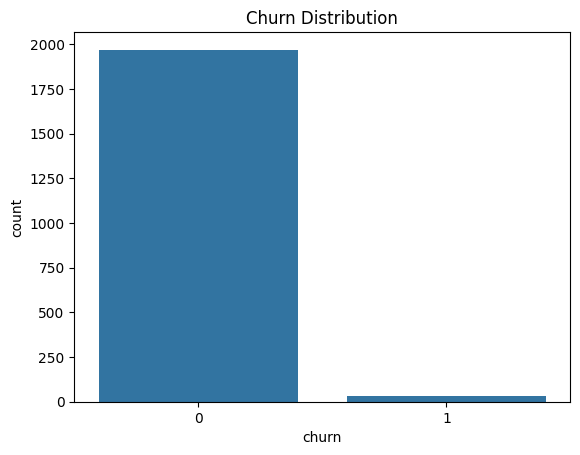

In [1]:
# =========================
# Task 1: Dataset Understanding
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("customer_churn_nn.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn types:")
print(df.dtypes)

print("\nTarget variable description:")
print(df['churn'].value_counts())

print("\nMissing values check:")
print(df.isnull().sum())

print("\nBasic statistical summary:")
print(df.describe())

sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()


In [2]:
# =========================
# Task 2: Data Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop identifier
df = df.drop(columns=['customer_id'])

# Encode categorical features
categorical_cols = ['region','plan_type','contract_type','payment_method']
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Scale numerical features
scaler = StandardScaler()
num_cols = [c for c in df_encoded.columns if c not in ['churn']]
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Split data
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [3]:
# =========================
# Task 3: Neural Network Model Building
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9356 - loss: 0.2629 - val_accuracy: 0.9850 - val_loss: 0.0865
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0802 - val_accuracy: 0.9850 - val_loss: 0.0708
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0735 - val_accuracy: 0.9850 - val_loss: 0.0654
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0666 - val_accuracy: 0.9850 - val_loss: 0.0621
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0623 - val_accuracy: 0.9850 - val_loss: 0.0608
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0580 - val_accuracy: 0.9850 - val_loss: 0.0587
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0541 - val_accuracy: 0.9850 - val_loss: 0.0582
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0511 - val_accuracy: 0.9850 - val_loss:

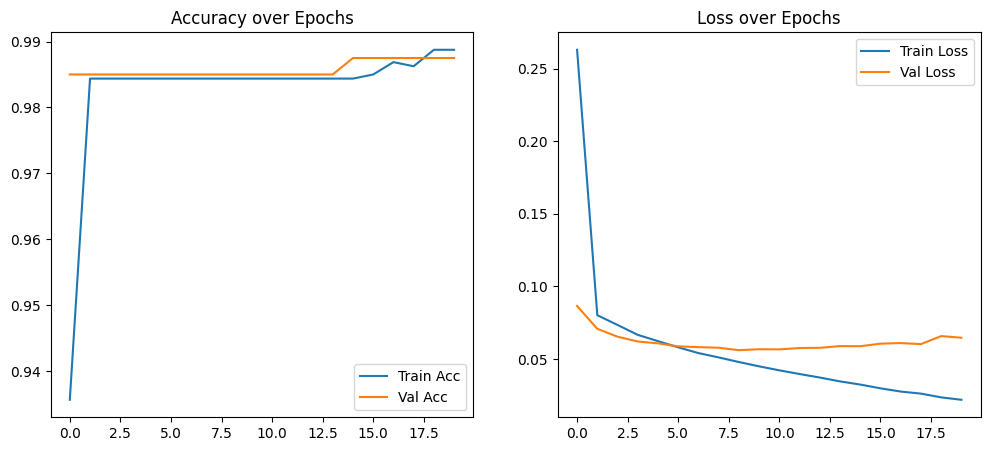

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Confusion Matrix:
 [[394   0]
 [  5   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       1.00      0.17      0.29         6

    accuracy                           0.99       400
   macro avg       0.99      0.58      0.64       400
weighted avg       0.99      0.99      0.98       400



In [4]:
# =========================
# Task 4: Training and Evaluation
# =========================
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=20, batch_size=32)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}, Loss: {loss:.4f}")

# Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [5]:
# =========================
# Task 5: Hyperparameter Experimentation
# =========================
results = []

def run_experiment(hidden_units=64, lr=0.001, batch_size=32, epochs=10):
    model = Sequential([
        Dense(hidden_units, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(hidden_units//2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=epochs,
                        batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results.append([hidden_units, lr, batch_size, epochs, acc])

# Run 3 experiments
run_experiment(hidden_units=32, lr=0.001, batch_size=32, epochs=10)
run_experiment(hidden_units=64, lr=0.005, batch_size=64, epochs=15)
run_experiment(hidden_units=128, lr=0.0005, batch_size=32, epochs=20)

import pandas as pd
results_df = pd.DataFrame(results, columns=['Hidden Units','Learning Rate','Batch Size','Epochs','Test Accuracy'])
print(results_df)
results_df.to_csv("model_comparison_table.csv", index=False)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Hidden Units  Learning Rate  Batch Size  Epochs  Test Accuracy
0            32         0.0010          32      10         0.9850
1            64         0.0050          64      15         0.9850
2           128         0.0005          32      20         0.9875


In [6]:
# =========================
# Task 6: Final Reflection
# =========================
reflection = """
- Weights and biases adjust during training to minimize loss and capture patterns in customer behavior.
- Activation functions (like ReLU) introduce non-linearity, allowing the network to learn complex relationships.
- A too-high learning rate causes unstable training; too-low makes convergence very slow.
- Underfitting occurs when the model is too simple; overfitting when it memorizes training data but fails on test data.
"""
print(reflection)



- Weights and biases adjust during training to minimize loss and capture patterns in customer behavior.
- Activation functions (like ReLU) introduce non-linearity, allowing the network to learn complex relationships.
- A too-high learning rate causes unstable training; too-low makes convergence very slow.
- Underfitting occurs when the model is too simple; overfitting when it memorizes training data but fails on test data.

